In [1]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import fitsio
import scienceplots
plt.style.use(['science','notebook','grid'])
from astropy.table import Table
import glob
from scipy.optimize import curve_fit as cf



/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]


z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
dL = cosmo.comoving_distance(samples_sorted).to(u.Mpc).value
num  = np.trapz(dL*n_z**2, z)
denom  = np.trapz(n_z**2, z)
chi_eff = num/denom
def theta_to_r(theta_deg):
    return chi_eff * np.deg2rad(theta_deg)

def r_to_theta(r_mpc):
    return np.rad2deg(r_mpc / chi_eff)


zeff = np.trapz(z*n_z, z) /np.trapz(n_z, z)
print('zeff = ', zeff)
dc_zeff= cosmo.comoving_distance(zeff).to(u.Mpc).value
dc_zeff

def theta_to_r_dc(theta_deg):
    return dc_zeff * np.deg2rad(theta_deg)
def r_to_theta_dc(r_mpc):
    return np.rad2deg(r_mpc / dc_zeff)

zeff =  0.09152033323313183


In [20]:
cosmo_hmcode = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index,
    ,matter_power_spectrum="camb",
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020",

        }
    }

)

cosmo_halofit = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index
)


theta = np.logspace(np.log10(1e-2), np.log10(15), 40) # degrees


bias = np.ones_like(z) * 1
ell = np.arange(2, 2000)
tr_hm = ccl.NumberCountsTracer(cosmo_hmcode, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_hm = ccl.angular_cl(cosmo_hmcode, tr_hm, tr_hm, ell)
wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hmcode)




In [21]:
def w_theta_func(theta,a):
    bias = a*np.ones_like(z) #+ 0.5*z
    tr_hm = ccl.NumberCountsTracer(cosmo_hmcode, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
    cl_hm = ccl.angular_cl(cosmo_hmcode, tr_hm, tr_hm, ell)
    wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hmcode)
    return wtheta_hm

def w_theta_func_halofit(theta,a):
    bias = a*np.ones_like(z) #+ 0.5*z
    tr = ccl.NumberCountsTracer(cosmo_halofit, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
    cl = ccl.angular_cl(cosmo_halofit, tr, tr, ell)
    wtheta = ccl.correlation(theta = theta, ell = ell, C_ell = cl, cosmo = cosmo_halofit)
    return wtheta

In [22]:
south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_100_1000_0.01_to_15.npy')
north = np.load('/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_100_1000_0.01_to_15.npy')
full = np.load('/user/animesh.sah/w_theta_results/treecorr_full_bootstrap_patches_100_1000_0.01_to_15.npy')

In [23]:
r_to_theta_dc(9), theta_to_r_dc(0.9)

(1.2998360455048141, 6.2315551472910755)

In [24]:
upper_scale=15
lower_scale=0.9
mask_north= (north[0]<upper_scale) & (north[0]>lower_scale)
mask_south= (south[0]<upper_scale) & (south[0]>lower_scale)
mask_full= (full[0]<upper_scale) & (full[0]>lower_scale)
popt_north,pcov_north = cf(w_theta_func,north[0][mask_north],north[1][mask_north],sigma=north[2][mask_north])
popt_south,pcov_south = cf(w_theta_func,south[0][mask_south],south[1][mask_south],sigma=south[2][mask_south])
popt_full,pcov_full = cf(w_theta_func,full[0][mask_full],full[1][mask_full],sigma=full[2][mask_full])
popt_full_halofit,pcov_full_halofit = cf(w_theta_func_halofit,full[0][mask_full],full[1][mask_full],sigma=full[2][mask_full])
popt_north, popt_south , popt_full , popt_full_halofit


(array([1.67616613]),
 array([1.93846182]),
 array([1.91635822]),
 array([1.9177871]))

In [30]:
w_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_full_jackknife_patches_30_0.01_to_15_w_True.npy')




popt_full_weight,pcov_full_weight = cf(w_theta_func,w_weights[0],w_weights[1],sigma=w_weights[2])

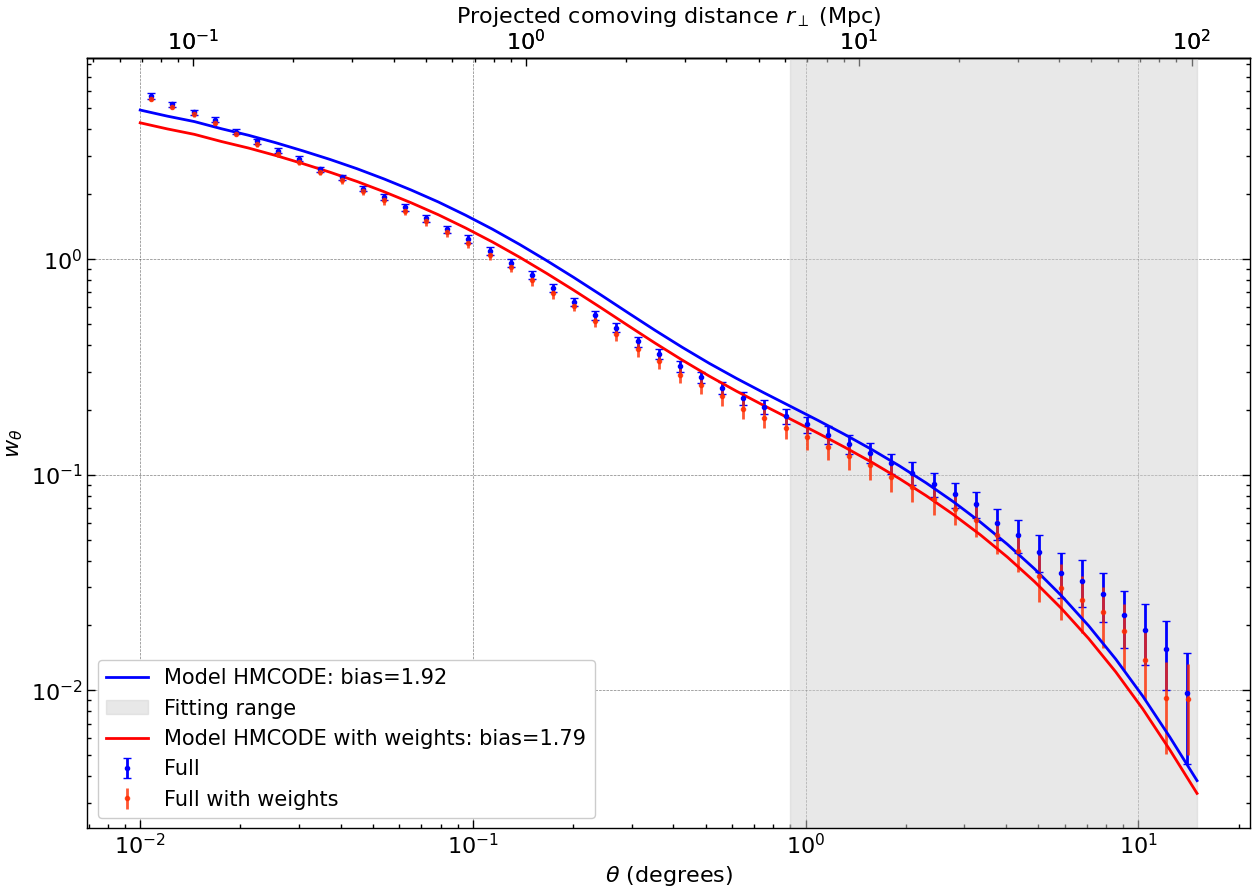

In [33]:
fig, ax = plt.subplots(figsize=(15,10))

ax.errorbar(full[0],full[1],yerr =full[2],fmt='.',label='Full',capsize= 3,color='blue')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
plt.yscale('log')
plt.errorbar(w_weights[0], w_weights[1], yerr=w_weights[2], label='Full with weights', color='C3', ls = 'None',marker='.',alpha=0.8)
plt.loglog(theta,w_theta_func(theta,popt_full),label=f'Model HMCODE: bias={popt_full[0]:.2f}',color='blue')
#plt.loglog(theta,w_theta_func_halofit(theta,popt_full_halofit),label=f'Model Halofit: bias={popt_full_halofit[0]:.2f}',color='cyan',linestyle='--')
plt.axvspan(lower_scale,upper_scale, color='lightgray', alpha=0.5,label='Fitting range')

plt.loglog(theta,w_theta_func(theta,popt_full_weight),label=f'Model HMCODE with weights: bias={popt_full_weight[0]:.2f}',color='red')
plt.legend(fontsize=15)

#### Adding secondary x-axis for projected comoving distance ####
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)



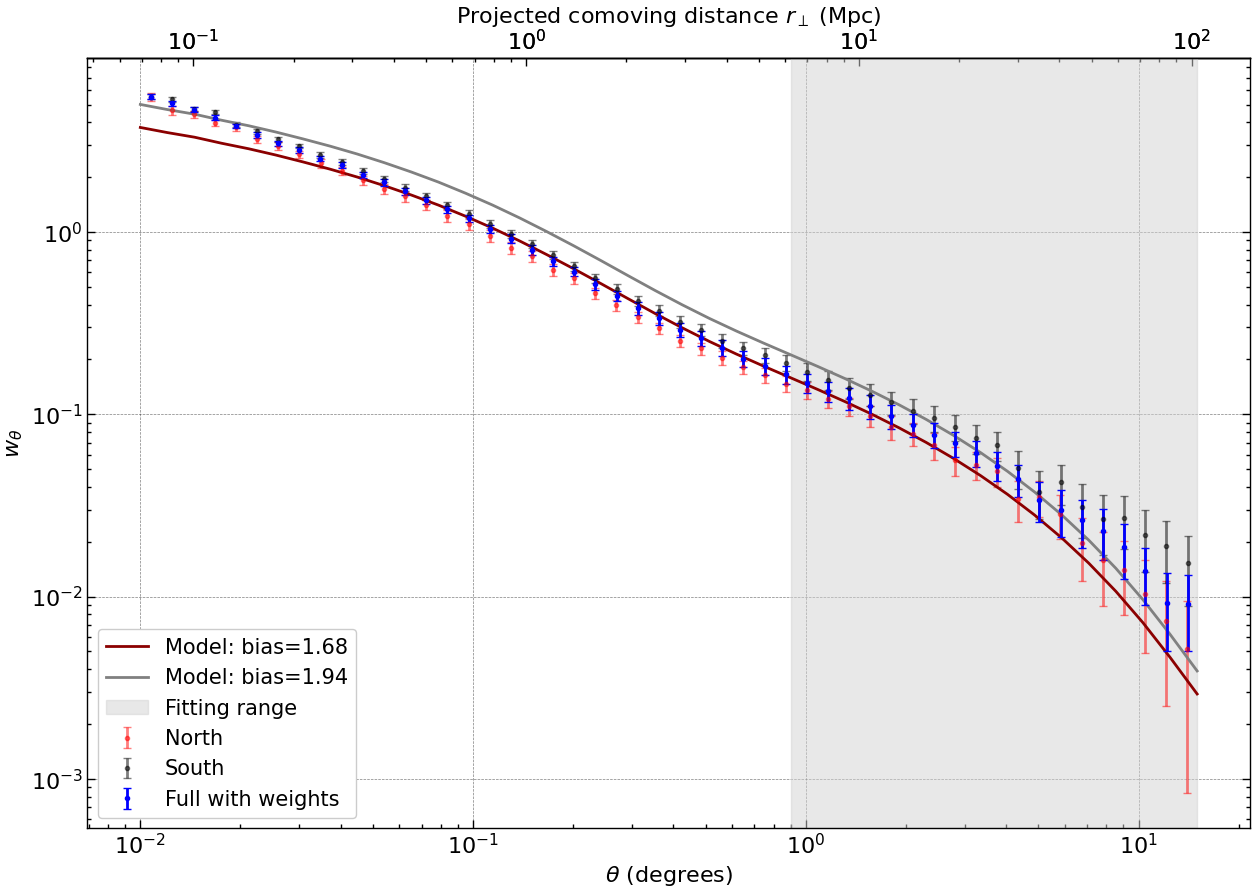

In [44]:
fig, ax = plt.subplots(figsize=(15,10))

ax.errorbar(north[0],north[1],yerr =north[2],fmt='.',label='North',capsize= 3,color='red',alpha=0.5)
ax.errorbar(south[0],south[1],yerr =south[2],fmt='.',label='South',capsize= 3,color='k',alpha=0.5)
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
plt.yscale('log')
plt.loglog(theta,w_theta_func(theta,popt_north),label=f'Model: bias={popt_north[0]:.2f}',color='darkred')
plt.loglog(theta,w_theta_func(theta,popt_south),label=f'Model: bias={popt_south[0]:.2f}',color='gray')
plt.axvspan(lower_scale,upper_scale, color='lightgray', alpha=0.5,label='Fitting range')
plt.errorbar(w_weights[0], w_weights[1], yerr=w_weights[2], label='Full with weights', color='blue', ls = 'None',marker='.',alpha=1,capsize=3)

plt.legend(fontsize=15)


#### Adding secondary x-axis for projected comoving distance ####
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)



5.714285714285714

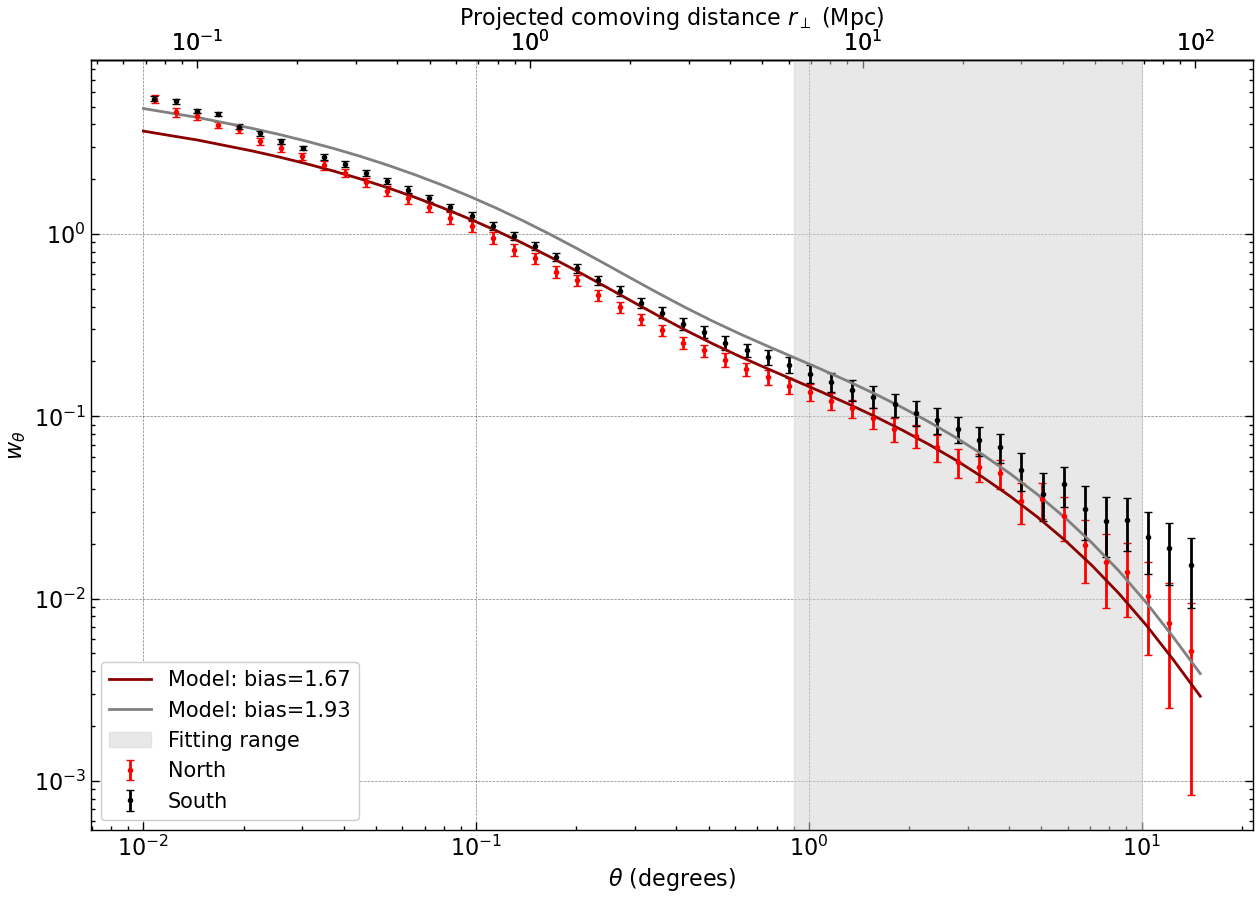

In [28]:
fig, ax = plt.subplots(figsize=(15,10))

ax.errorbar(north[0],north[1],yerr =north[2],fmt='.',label='North',capsize= 3,color='red')
ax.errorbar(south[0],south[1],yerr =south[2],fmt='.',label='South',capsize= 3,color='k')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
plt.yscale('log')
plt.loglog(theta,w_theta_func(theta,popt_north),label=f'Model: bias={popt_north[0]:.2f}',color='darkred')
plt.loglog(theta,w_theta_func(theta,popt_south),label=f'Model: bias={popt_south[0]:.2f}',color='gray')
plt.axvspan(lower_scale,upper_scale, color='lightgray', alpha=0.5,label='Fitting range')
plt.legend(fontsize=15)


#### Adding secondary x-axis for projected comoving distance ####
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)



In [ ]:
r_to_theta_dc(10),

(1.4502249434029646, 68.95482004698471)

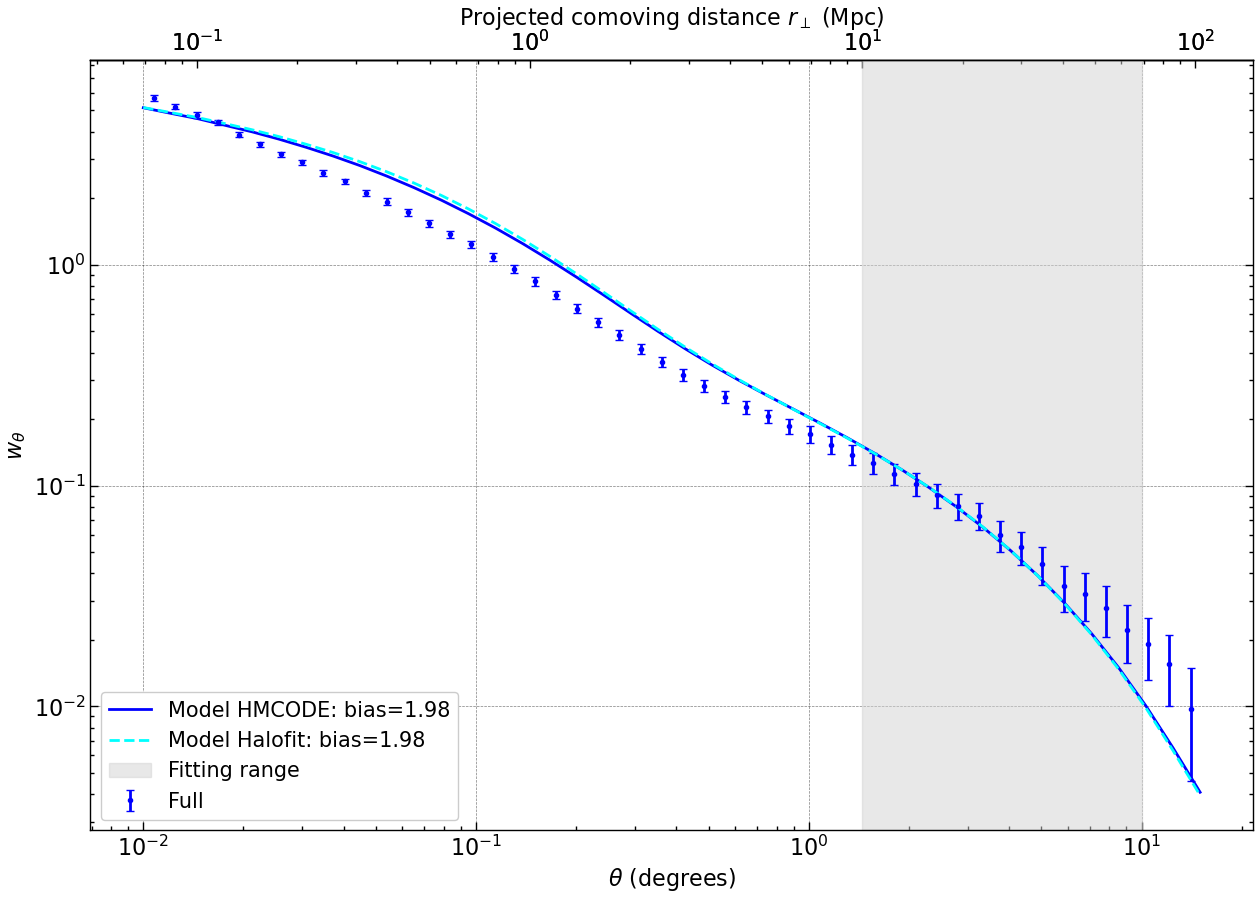

In [23]:
upper_scale=10
lower_scale=1.45
mask_north= (north[0]<upper_scale) & (north[0]>lower_scale)
mask_south= (south[0]<upper_scale) & (south[0]>lower_scale)
mask_full= (full[0]<upper_scale) & (full[0]>lower_scale)
popt_north,pcov_north = cf(w_theta_func,north[0][mask_north],north[1][mask_north],sigma=north[2][mask_north])
popt_south,pcov_south = cf(w_theta_func,south[0][mask_south],south[1][mask_south],sigma=south[2][mask_south])
popt_full,pcov_full = cf(w_theta_func,full[0][mask_full],full[1][mask_full],sigma=full[2][mask_full])
popt_full_halofit,pcov_full_halofit = cf(w_theta_func_halofit,full[0][mask_full],full[1][mask_full],sigma=full[2][mask_full])
popt_north, popt_south , popt_full , popt_full_halofit

fig, ax = plt.subplots(figsize=(15,10))

ax.errorbar(full[0],full[1],yerr =full[2],fmt='.',label='Full',capsize= 3,color='blue')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
plt.yscale('log')
plt.loglog(theta,w_theta_func(theta,popt_full),label=f'Model HMCODE: bias={popt_full[0]:.2f}',color='blue')
plt.loglog(theta,w_theta_func_halofit(theta,popt_full_halofit),label=f'Model Halofit: bias={popt_full_halofit[0]:.2f}',color='cyan',linestyle='--')
plt.axvspan(lower_scale,upper_scale, color='lightgray', alpha=0.5,label='Fitting range')
plt.legend(fontsize=15)


#### Adding secondary x-axis for projected comoving distance ####
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

